## Thông tin về Dataset


Các nhà khoa học dữ liệu tại BigMart đã thu thập dữ liệu bán hàng năm 2013 cho 1559 sản phẩm tại 10 cửa hàng ở các thành phố khác nhau. Đồng thời, một số thuộc tính của từng sản phẩm và cửa hàng cũng đã được xác định. Mục tiêu là xây dựng một mô hình dự đoán để ước lượng doanh số của một sản phẩm tại một cửa hàng cụ thể.

Sử dụng mô hình này, BigMart sẽ cố gắng hiểu các đặc tính của sản phẩm và cửa hàng nào đóng vai trò quan trọng trong việc tăng doanh số.


Variable | Description
----------|--------------
Item_Identifier | Mã sản phẩm
Item_Weight | Trọng lượng của sản phẩm
Item_Fat_Content | Cho biết sản phẩm có hàm lượng chất béo thấp hay không
Item_Visibility | % diện tích trưng bày của sản phẩm
Item_Type | Loại sản phẩm
Item_MRP | Giá bán lẻ tối đa (giá niêm yết) của sản phẩm
Outlet_Identifier | Mã cửa hàng
Outlet_Establishment_Year | Năm thành lập cửa hàng
Outlet_Size | Kích thước cửa hàng dựa trên diện tích mặt bằng
Outlet_Location_Type | Loại thành phố nơi cửa hàng tọa lạc
Outlet_Type | Loại cửa hàng (cửa hàng tạp hóa, siêu thị,...)
Item_Outlet_Sales | Doanh số sản phẩm tại cửa hàng đó (đây là biến kết quả cần dự đoán)

## Import modules

In [181]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

## Tải dataset


In [182]:
df = pd.read_csv('Train.csv')
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [183]:
# Thông tin thống kê cơ bản
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [184]:
# Kiểu dữ liệu của các thuộc tính (cột)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [185]:
# Kiểm tra thuộc tín
df.apply(lambda x: len(x.unique()))

,0
Item_Identifier,1559
Item_Weight,416
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,4
Outlet_Location_Type,3


## Tiền xử lý dữ liệu

In [186]:
# Kiểm tra null values
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [187]:
# kiểm tra các thuộc tính là object
cat_col = []
for x in df.dtypes.index:
    if df.dtypes[x] == 'object':
        cat_col.append(x)
cat_col

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [188]:
# Loại bỏ các biến định danh duy nhất
cat_col.remove('Item_Identifier')
cat_col.remove('Outlet_Identifier')
cat_col

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [189]:
# Danh sách các cột object
for col in cat_col:
    print(col)
    print(df[col].value_counts())
    print()

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Size
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

Outlet_Location_Type
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

Outlet_Type
Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2   

In [190]:
# Điền các giá trị bị thiếu cho Item_Weight bằng giá trị trung bình
item_weight_mean = df.pivot_table(values = "Item_Weight", index = 'Item_Identifier')
item_weight_mean

,Item_Weight
Item_Identifier,
DRA12,11.600
DRA24,19.350
DRA59,8.270
DRB01,7.390
DRB13,6.115
...,...
NCZ30,6.590
NCZ41,19.850
NCZ42,10.500


In [191]:
miss_bool = df['Item_Weight'].isnull()
miss_bool

,Item_Weight
0,False
1,False
2,False
3,False
4,False
...,...
8518,False
8519,False
8520,False
8521,False


In [192]:
for i, item in enumerate(df['Item_Identifier']):
    if miss_bool[i]:
        if item in item_weight_mean:
            df['Item_Weight'][i] = item_weight_mean.loc[item]['Item_Weight']
        else:
            df['Item_Weight'][i] = np.mean(df['Item_Weight'])

In [193]:
df['Item_Weight'].isnull().sum() # Kiểm tra xem còn giá trị null không

np.int64(0)

In [194]:
# Điền các giá trị bị thiếu cho Outlet_Size bằng giá trị trung bình
outlet_size_mode = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))
outlet_size_mode

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [195]:
miss_bool = df['Outlet_Size'].isnull()
df.loc[miss_bool, 'Outlet_Size'] = df.loc[miss_bool, 'Outlet_Type'].apply(lambda x: outlet_size_mode[x])

In [196]:
df['Outlet_Size'].isnull().sum()

np.int64(0)

In [197]:
# Thay thế giá trị trung bình cho các sản phẩm có Item_Visibility bằng 0
sum(df['Item_Visibility']==0)

526

In [198]:
df.loc[:, 'Item_Visibility'].replace([0], [df['Item_Visibility'].mean()], inplace=True)

In [199]:
sum(df['Item_Visibility']==0)

0

In [200]:
# Chuẩn hóa các giá trị trong Item_Fat_Content
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [201]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF':'Low Fat', 'reg':'Regular', 'low fat':'Low Fat'})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


## Tạo thuộc tính mới


In [202]:
# Lấy 2 ký tự đầu tiên của mã sản phẩm cho thuộc tính mới New_Item_Type
df['New_Item_Type'] = df['Item_Identifier'].apply(lambda x: x[:2])
df['New_Item_Type']

,New_Item_Type
0,FD
1,DR
2,FD
3,FD
4,NC
...,...
8518,FD
8519,FD
8520,NC
8521,FD


In [203]:
df['New_Item_Type'] = df['New_Item_Type'].map({'FD':'Food', 'NC':'Non-Consumable', 'DR':'Drinks'})
df['New_Item_Type'].value_counts()

,count
New_Item_Type,
Food,6125
Non-Consumable,1599
Drinks,799


In [204]:
df.loc[df['New_Item_Type']=='Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3918
Regular,3006
Non-Edible,1599


In [205]:
# Thêm thuộc tính mới Outlet_Years (Tuổi cửa hàng)
df['Outlet_Years'] = 2013 - df['Outlet_Establishment_Year']

In [206]:
df['Outlet_Years']

,Outlet_Years
0,14
1,4
2,14
3,15
4,26
...,...
8518,26
8519,11
8520,9
8521,4


In [207]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Food,14
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Drinks,4
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Food,14
3,FDX07,19.200,Regular,0.066132,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,Food,15
4,NCD19,8.930,Non-Edible,0.066132,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,Food,26
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Small,Tier 2,Supermarket Type1,549.2850,Food,11
8520,NCJ29,10.600,Non-Edible,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,Non-Consumable,9
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,Food,4


## Khám phá dữ liệu (Exploratory Data Analysis)

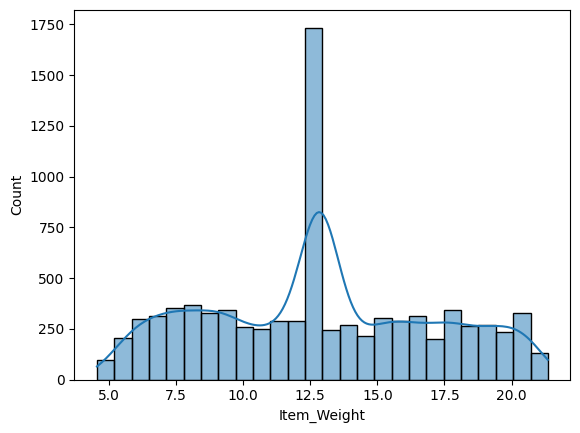

In [208]:
# Biểu đồ phân phối
sns.histplot(df['Item_Weight'], kde=True)
plt.show()

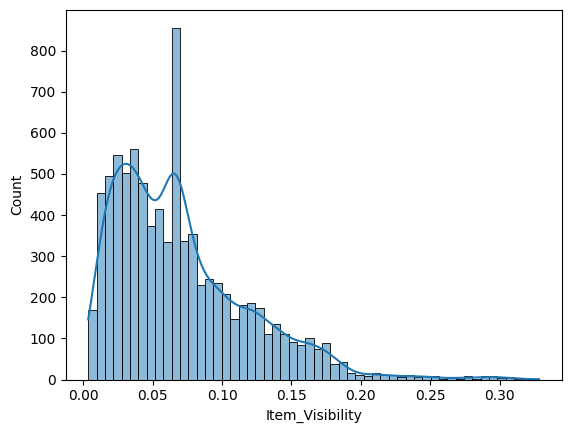

In [209]:
sns.histplot(df['Item_Visibility'], kde=True)
plt.show()

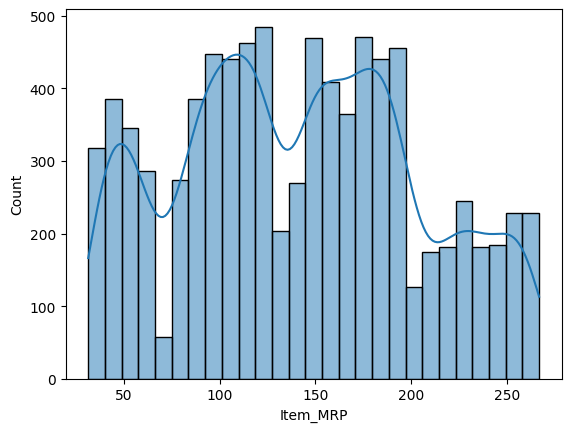

In [210]:
sns.histplot(df['Item_MRP'], kde=True)
plt.show()

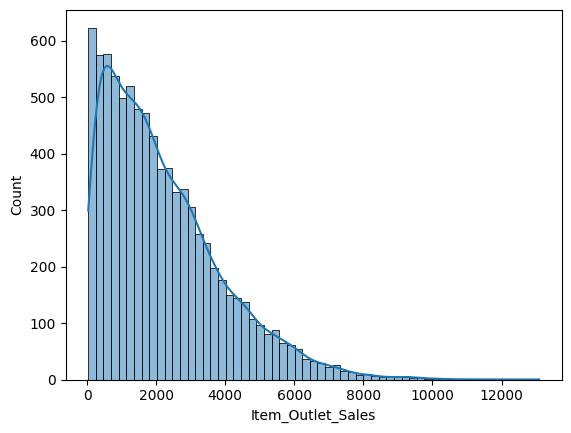

In [211]:
sns.histplot(df['Item_Outlet_Sales'], kde=True)
plt.show()

In [212]:
# Log transformation để học ổn định hơn
df['Item_Outlet_Sales'] = np.log(1+df['Item_Outlet_Sales']) #ln

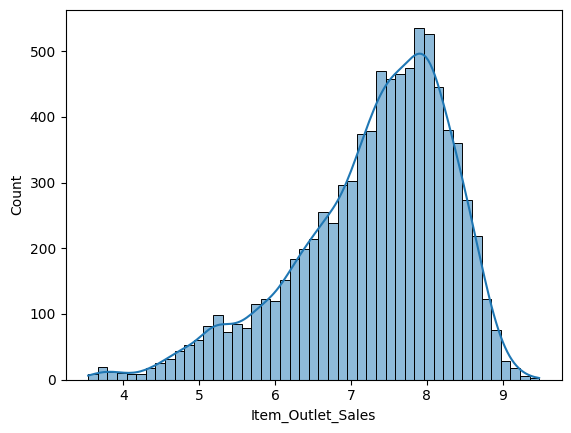

In [213]:
sns.histplot(df['Item_Outlet_Sales'], kde=True)
plt.show()

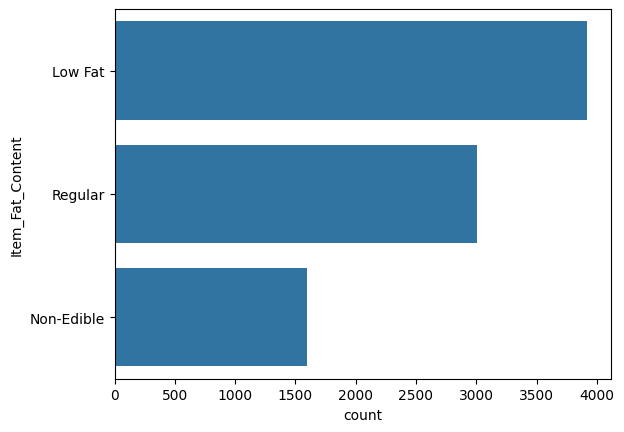

In [214]:
sns.countplot(df["Item_Fat_Content"])
plt.show()

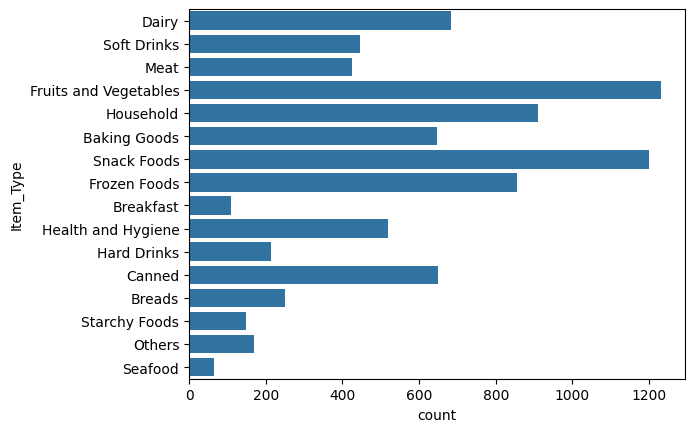

In [215]:
chart = sns.countplot(y=df["Item_Type"])
plt.show()

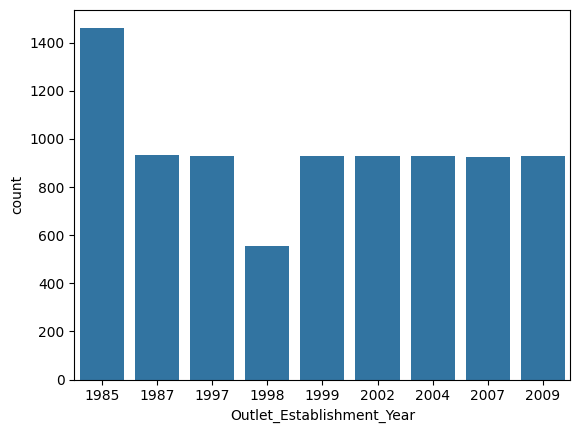

In [216]:
sns.countplot(x='Outlet_Establishment_Year', data=df)
plt.show()

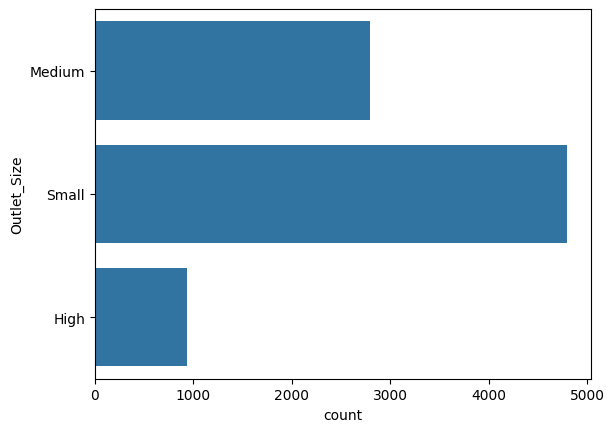

In [217]:
sns.countplot(df['Outlet_Size'])
plt.show()

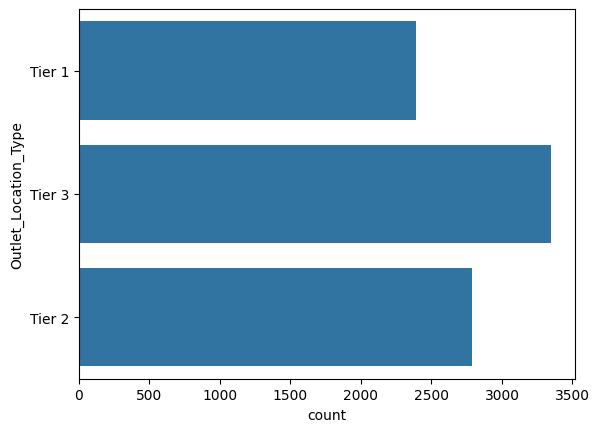

In [218]:
sns.countplot(df['Outlet_Location_Type'])
plt.show()

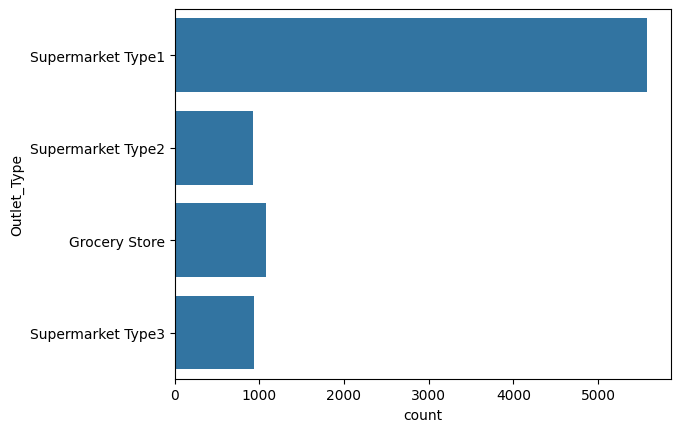

In [219]:
sns.countplot(df['Outlet_Type'])
plt.show()

## Ma trận tương quan



<Axes: >

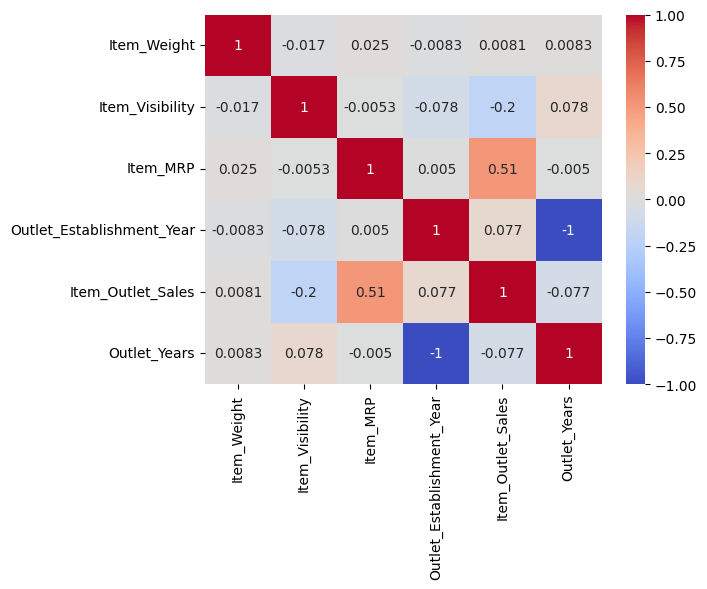

In [220]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [221]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.225808,Food,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.096776,Drinks,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.648868,Food,14
3,FDX07,19.20,Regular,0.066132,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,6.597664,Food,15
4,NCD19,8.93,Non-Edible,0.066132,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.903451,Non-Consumable,26


## Mã hóa biến phân loại

In [222]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Outlet'] = le.fit_transform(df['Outlet_Identifier'])
cat_col = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'New_Item_Type']
for col in cat_col:
    df[col] = le.fit_transform(df[col])

In [223]:
# Onehot Encoding
df = pd.get_dummies(df, columns=['Item_Fat_Content', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'New_Item_Type'])
df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Years,Outlet,...,Outlet_Location_Type_0,Outlet_Location_Type_1,Outlet_Location_Type_2,Outlet_Type_0,Outlet_Type_1,Outlet_Type_2,Outlet_Type_3,New_Item_Type_0,New_Item_Type_1,New_Item_Type_2
0,FDA15,9.30,0.016047,4,249.8092,OUT049,1999,8.225808,14,9,...,True,False,False,False,True,False,False,False,True,False
1,DRC01,5.92,0.019278,14,48.2692,OUT018,2009,6.096776,4,3,...,False,False,True,False,False,True,False,True,False,False
2,FDN15,17.50,0.016760,10,141.6180,OUT049,1999,7.648868,14,9,...,True,False,False,False,True,False,False,False,True,False
3,FDX07,19.20,0.066132,6,182.0950,OUT010,1998,6.597664,15,0,...,False,False,True,True,False,False,False,False,True,False
4,NCD19,8.93,0.066132,9,53.8614,OUT013,1987,6.903451,26,1,...,False,False,True,False,True,False,False,False,False,True


## Input Split

In [224]:
X = df.drop(columns=['Outlet_Establishment_Year', 'Item_Identifier', 'Outlet_Identifier', 'Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']
X

,Item_Weight,Item_Visibility,Item_Type,Item_MRP,Outlet_Years,Outlet,Item_Fat_Content_0,Item_Fat_Content_1,Item_Fat_Content_2,Outlet_Size_0,...,Outlet_Location_Type_0,Outlet_Location_Type_1,Outlet_Location_Type_2,Outlet_Type_0,Outlet_Type_1,Outlet_Type_2,Outlet_Type_3,New_Item_Type_0,New_Item_Type_1,New_Item_Type_2
0,9.300,0.016047,4,249.8092,14,9,True,False,False,False,...,True,False,False,False,True,False,False,False,True,False
1,5.920,0.019278,14,48.2692,4,3,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
2,17.500,0.016760,10,141.6180,14,9,True,False,False,False,...,True,False,False,False,True,False,False,False,True,False
3,19.200,0.066132,6,182.0950,15,0,False,False,True,False,...,False,False,True,True,False,False,False,False,True,False
4,8.930,0.066132,9,53.8614,26,1,False,True,False,True,...,False,False,True,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0.056783,13,214.5218,26,1,True,False,False,True,...,False,False,True,False,True,False,False,False,True,False
8519,8.380,0.046982,0,108.1570,11,7,False,False,True,False,...,False,True,False,False,True,False,False,False,True,False
8520,10.600,0.035186,8,85.1224,9,6,False,True,False,False,...,False,True,False,False,True,False,False,False,False,True
8521,7.210,0.145221,13,103.1332,4,3,False,False,True,False,...,False,False,True,False,False,True,False,False,True,False


In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [226]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [227]:
# Hàm đánh giá
def evaluate_mse(y_true, y_pred):
    """
    Tính Mean Squared Error (MSE)
    mse = np.mean((y_true - y_pred) ** 2)
    """
    return mean_squared_error(y_true, y_pred)


def evaluate_mae(y_true, y_pred):
    """
    Tính Mean Absolute Error (MAE)
    mae = np.mean(np.abs(y_true - y_pred))
    """
    return mean_absolute_error(y_true, y_pred)


def evaluate_r2(y_true, y_pred):
    """
    Tính R-squared (R²)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    """
    return r2_score(y_true, y_pred)



# Hàm huấn luyện
def train(model, X, y, cv=5):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    train_mse = evaluate_mse(y_train, y_train_pred)
    train_mae = evaluate_mae(y_train, y_train_pred)
    train_r2 = evaluate_r2(y_train, y_train_pred)

    test_mse = evaluate_mse(y_test, y_test_pred)
    test_mae = evaluate_mae(y_test, y_test_pred)
    test_r2 = evaluate_r2(y_test, y_test_pred)

    print(f"===== Model Report =====")
    print(f"Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Test MAE: {test_mae:.4f}")
    print(f"Train R²:  {train_r2:.4f} | Test R²:  {test_r2:.4f}")
    print(f"Overfitting: {(train_mse - test_mse)/train_mse*100:.2f}%")
    print()

    return {
        'train_mse': train_mse, 'test_mse': test_mse,
        'train_mae': train_mae, 'test_mae': test_mae,
        'train_r2': train_r2, 'test_r2': test_r2
    }

## Linear Regression

In [228]:
# Linear Regression thủ công
class OurLinearRegression:
    """
    Linear Regression:
        w = (X^T X)^(-1) X^T y
    Sử dụng pseudo-inverse (pinv) để ổn định hơn khi ma trận X^T X không khả nghịch.
    """

    def __init__(self, fit_intercept: bool = True):
        self.fit_intercept = fit_intercept # fit_intercept: nếu True thêm cột 1 để học hệ số chặn (intercept)
        self.w = None  # vector trọng số (weights): [intercept, coef_1, coef_2, ...]

    @property
    def coef_(self):
        if self.w is None:
            raise ValueError("Model chưa được train!")
        return self.w[1:] if self.fit_intercept else self.w

    @property
    def intercept_(self):
        if not self.fit_intercept:
            return 0.0
        if self.w is None:
            raise ValueError("Model chưa được train!")
        return self.w[0]

    def fit(self, X, y):
        # Ép kiểu dữ liệu sang float
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        # Nếu có intercept → thêm cột 1 vào đầu ma trận X
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1))     # tạo cột 1
            X = np.hstack((ones, X))            # ghép vào X

        self.w = np.linalg.pinv(X.T @ X) @ X.T @ y # w = (XᵀX)^(-1) Xᵀy

    def predict(self, X):
        if self.w is None:
            raise ValueError("Model chưa được train!")

        X = np.array(X, dtype=float)

        # Nếu có intercept thêm cột 1 vào đầu ma trận X
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1))
            X = np.hstack((ones, X))

        # Dự đoán: ŷ = Xw
        return X @ self.w


model = OurLinearRegression(fit_intercept=True)
train(model, X, y)
print()

===== Model Report =====
Train MSE: 0.2893 | Test MSE: 0.2839
Train MAE: 0.4163 | Test MAE: 0.4150
Train R²:  0.7177 | Test R²:  0.7299
Overfitting: 1.86%




===== Model Report =====
Train MSE: 0.2893 | Test MSE: 0.2839
Train MAE: 0.4163 | Test MAE: 0.4150
Train R²:  0.7177 | Test R²:  0.7299
Overfitting: 1.86%



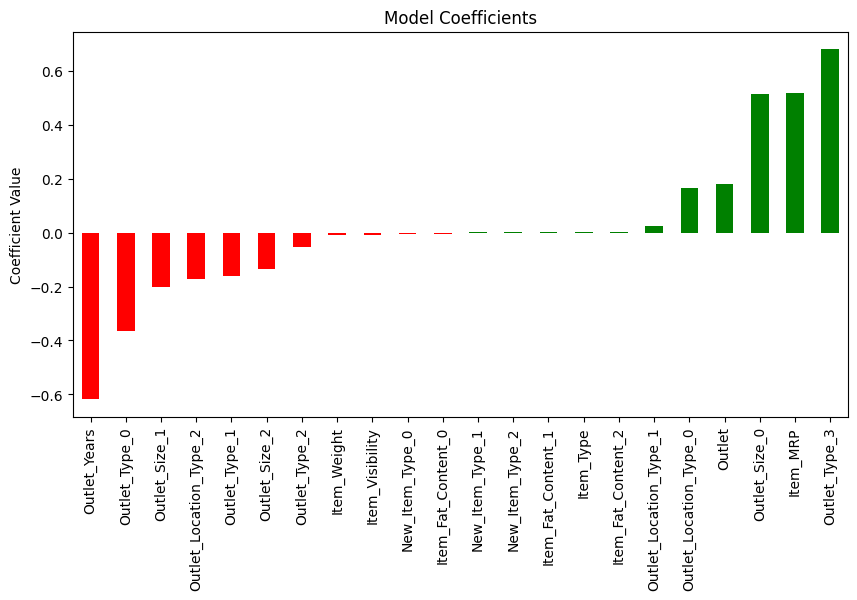

In [229]:
# Hồi quy tuyến tính thư viện
model = make_pipeline(StandardScaler(), LinearRegression())
train(model, X, y)

# Lấy hệ số (vì model nằm trong pipeline)
coef = pd.Series(model.named_steps['linearregression'].coef_, index=X.columns).sort_values()

# Vẽ biểu đồ
coef.plot(kind='bar', figsize=(10,5),
          title="Model Coefficients",
          color=['red' if v < 0 else 'green' for v in coef])
plt.ylabel("Coefficient Value")
plt.show()

===== Model Report =====
Train MSE: 0.2893 | Test MSE: 0.2841
Train MAE: 0.4163 | Test MAE: 0.4152
Train R²:  0.7176 | Test R²:  0.7298
Overfitting: 1.81%



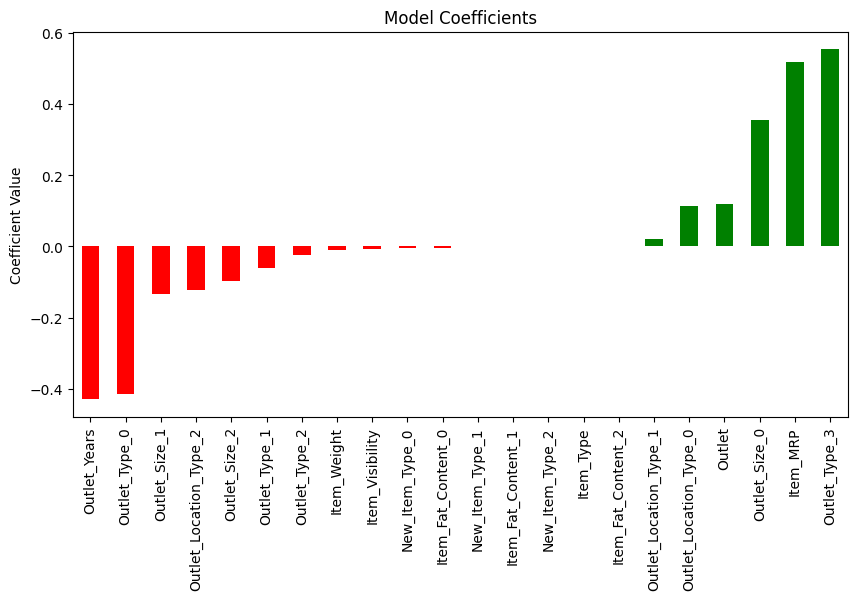

In [230]:
model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
train(model, X, y)

coef = pd.Series(model.named_steps['ridge'].coef_, index=X.columns).sort_values()

coef.plot(kind='bar', figsize=(10,5),
          title="Model Coefficients",
          color=['red' if v < 0 else 'green' for v in coef])
plt.ylabel("Coefficient Value")
plt.show()

===== Model Report =====
Train MSE: 0.2897 | Test MSE: 0.2849
Train MAE: 0.4165 | Test MAE: 0.4162
Train R²:  0.7173 | Test R²:  0.7290
Overfitting: 1.66%



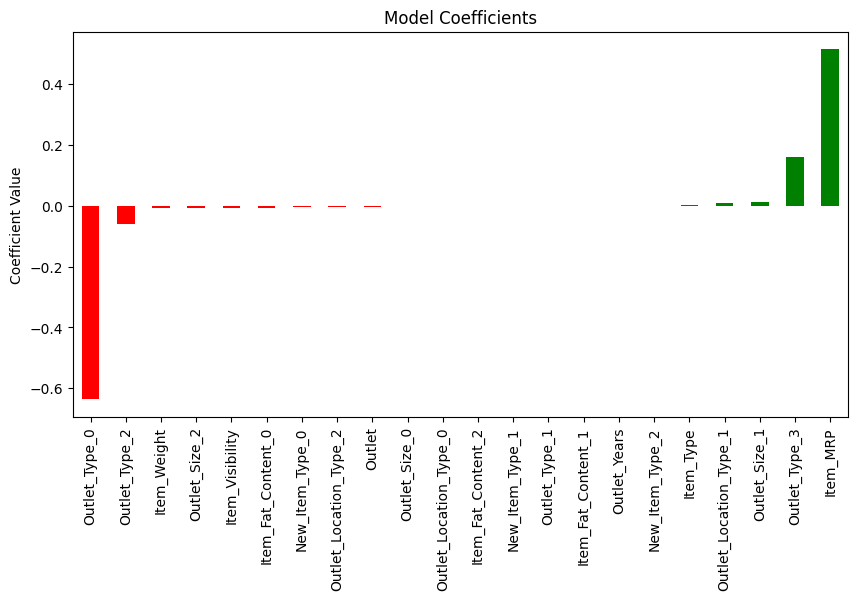

In [231]:
model = make_pipeline(StandardScaler(), Lasso(alpha=0.001))
train(model, X, y)

coef = pd.Series(model.named_steps['lasso'].coef_, index=X.columns).sort_values()

coef.plot(kind='bar', figsize=(10,5),
          title="Model Coefficients",
          color=['red' if v < 0 else 'green' for v in coef])
plt.ylabel("Coefficient Value")
plt.show()

## Decision Tree

In [232]:
class OurDecisionTreeRegressor:
    """
        Ở mỗi node, chọn (feature, threshold) sao cho giảm MSE nhiều nhất.
        Dừng khi đạt max_depth hoặc số mẫu < min_samples_split.
        Node lá dự đoán bằng trung bình của các giá trị y trong node đó.
    """

    def __init__(self, max_depth: int = 5, min_samples_split: int = 2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split # Số mẫu nhỏ nhất cần có để tiếp tục chia nhánh
        self.tree_ = None

    def fit(self, X, y):
        """
        Huấn luyện cây hồi quy trên tập dữ liệu (X, y)
        """
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        # Gọi hàm đệ quy xây dựng cây
        self.tree_ = self._build_tree(X, y, depth=0)

    def predict(self, X):
        if self.tree_ is None:
            raise ValueError("Model chưa được train!")

        X = np.array(X, dtype=float)
        # Dự đoán từng dòng dữ liệu (mẫu)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def _build_tree(self, X, y, depth):
        """
        Xây dựng cây đệ quy:
        - Chọn feature và threshold tốt nhất để chia nhánh.
        - Trả về node (dict) hoặc giá trị trung bình nếu là node lá.
        """
        n_samples, n_features = X.shape

        # Điều kiện dừng
        if (depth >= self.max_depth) or (n_samples < self.min_samples_split):
            # Trả về giá trị trung bình y trong node (node lá)
            return np.mean(y)

        best_feature, best_threshold, best_mse = None, None, np.inf

        # Duyệt qua tất cả các đặc trưng
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])  # Các giá trị có thể chia
            for t in thresholds:
                # Chia dữ liệu thành 2 nhánh
                left_idx = X[:, feature_idx] <= t
                right_idx = X[:, feature_idx] > t

                # Bỏ qua nếu 1 nhánh trống
                if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
                    continue

                # Tính MSE sau khi chia
                mse = self._weighted_mse(y[left_idx], y[right_idx])

                # Cập nhật nếu tìm thấy cách chia tốt hơn
                if mse < best_mse:
                    best_feature = feature_idx
                    best_threshold = t
                    best_mse = mse

        # Nếu không thể chia tốt hơn, dừng lại
        if best_feature is None:
            return np.mean(y)

        # Chia dữ liệu theo ngưỡng tối ưu
        left_idx = X[:, best_feature] <= best_threshold
        right_idx = X[:, best_feature] > best_threshold

        # Đệ quy xây cây con
        left_subtree = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_subtree = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        return {
            "feature": best_feature,
            "threshold": best_threshold,
            "left": left_subtree,
            "right": right_subtree
        }

    def _predict_one(self, x, tree):
        """
        Dự đoán cho 1 mẫu x duy nhất bằng cách đi xuống cây.
        """
        # Nếu node hiện tại là giá trị (node lá) thì trả về
        if not isinstance(tree, dict):
            return tree

        # So sánh giá trị x[feature] với threshold để chọn nhánh
        if x[tree["feature"]] <= tree["threshold"]:
            return self._predict_one(x, tree["left"])
        else:
            return self._predict_one(x, tree["right"])

    def _weighted_mse(self, y_left, y_right):
        """
        Tính MSE có trọng số của 2 nhánh con (trái/phải)
        """
        n_left, n_right = len(y_left), len(y_right)
        total = n_left + n_right

        # MSE của từng nhánh
        mse_left = np.mean((y_left - np.mean(y_left)) ** 2)
        mse_right = np.mean((y_right - np.mean(y_right)) ** 2)

        # Kết hợp theo trọng số kích thước từng nhánh
        return (n_left / total) * mse_left + (n_right / total) * mse_right

model = OurDecisionTreeRegressor(max_depth=7)
train(model, X, y)
print()

===== Model Report =====
Train MSE: 0.2483 | Test MSE: 0.3009
Train MAE: 0.3820 | Test MAE: 0.4206
Train R²:  0.7577 | Test R²:  0.7138
Overfitting: -21.20%




In [233]:
for depth in range(3, 13):
    model = OurDecisionTreeRegressor(max_depth=depth)
    model.fit(X, y)
    y_pred = model.predict(X)

    mse = evaluate_mse(y, y_pred)
    mae = evaluate_mae(y, y_pred)

    print(f"max_depth={depth}, MSE={mse:.4f}, MAE={mae:.4f}")

max_depth=3, MSE=0.3157, MAE=0.4377
max_depth=4, MSE=0.2844, MAE=0.4129
max_depth=5, MSE=0.2677, MAE=0.4009
max_depth=6, MSE=0.2590, MAE=0.3937
max_depth=7, MSE=0.2488, MAE=0.3845
max_depth=8, MSE=0.2385, MAE=0.3736
max_depth=9, MSE=0.2240, MAE=0.3595
max_depth=10, MSE=0.2066, MAE=0.3403
max_depth=11, MSE=0.1887, MAE=0.3177
max_depth=12, MSE=0.1684, MAE=0.2916


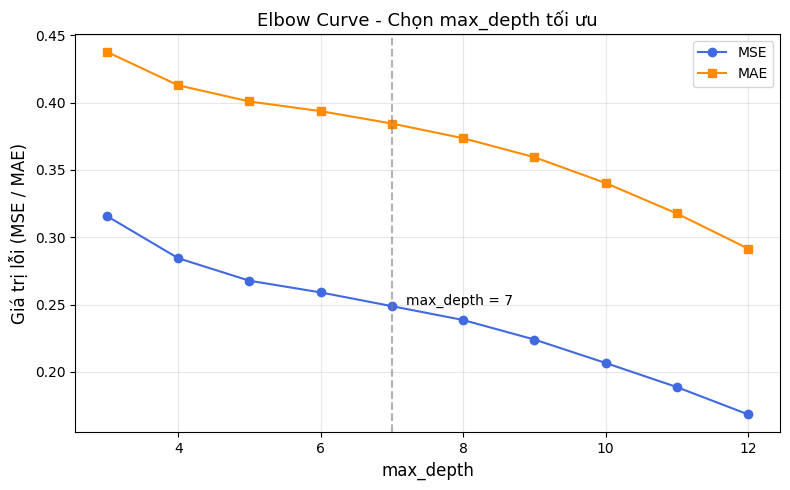

In [234]:
max_depth = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
mse = np.array([0.3157, 0.2844, 0.2677, 0.2590, 0.2488, 0.2385, 0.2240, 0.2066, 0.1887, 0.1684])
mae = np.array([0.4377, 0.4129, 0.4009, 0.3937, 0.3845, 0.3736, 0.3595, 0.3403, 0.3177, 0.2916])

# Vẽ biểu đồ
plt.figure(figsize=(8,5))
plt.plot(max_depth, mse, marker='o', label='MSE', color='royalblue')
plt.plot(max_depth, mae, marker='s', label='MAE', color='darkorange')

# Đánh dấu điểm "gấp khúc"
best_depth = 7
plt.axvline(best_depth, color='gray', linestyle='--', alpha=0.6)
plt.text(best_depth + 0.2, 0.25, f"max_depth = {best_depth}")

plt.title("Elbow Curve - Chọn max_depth tối ưu", fontsize=13)
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Giá trị lỗi (MSE / MAE)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

===== Model Report =====
Train MSE: 0.0000 | Test MSE: 0.5622
Train MAE: 0.0000 | Test MAE: 0.5731
Train R²:  1.0000 | Test R²:  0.4653
Overfitting: -161963505771995704690678677765095424.00%



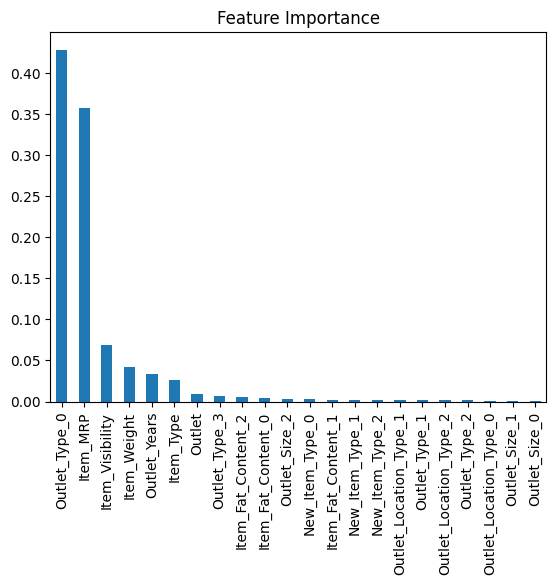

In [235]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
train(model, X, y)

coef = pd.Series(model.feature_importances_, X.columns).sort_values(ascending=False)
coef.plot(kind='bar', title="Feature Importance")
plt.show()

In [236]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=7)
train(model, X, y)

coef = pd.Series(model.feature_importances_, X.columns).sort_values(ascending=False)
plt.show()

===== Model Report =====
Train MSE: 0.2483 | Test MSE: 0.2937
Train MAE: 0.3822 | Test MAE: 0.4172
Train R²:  0.7576 | Test R²:  0.7206
Overfitting: -18.29%



## Random Forest

In [237]:
class OurRandomForestRegressor:
    """
    Gồm nhiều Decision Trees huấn luyện bằng Bootstrap Sampling.
    Dự đoán = trung bình dự đoán của các cây con.
    n_estimators : int
        Số lượng cây trong rừng.
    max_depth : int or None
        Độ sâu tối đa của mỗi cây.
    min_samples_split : int
        Số mẫu tối thiểu để tách node.
    random_state : int or None
        Tính ngẫu nhiên
    """

    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        """
        Huấn luyện n_estimators cây trên các mẫu bootstrap.
        """
        np.random.seed(self.random_state)
        self.trees = []
        X = np.array(X)
        y = np.array(y)

        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_sample = X[indices]
            y_sample = y[indices]

            # Huấn luyện cây con
            tree = OurDecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        """
        Dự đoán bằng cách trung bình hóa dự đoán từ tất cả các cây.
        """
        X = np.array(X)
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(preds, axis=0)


model = OurRandomForestRegressor(n_estimators=8, max_depth=6, random_state=42)
train(model, X, y)
print()

===== Model Report =====
Train MSE: 0.2533 | Test MSE: 0.2723
Train MAE: 0.3884 | Test MAE: 0.4031
Train R²:  0.7528 | Test R²:  0.7410
Overfitting: -7.49%




===== Model Report =====
Train MSE: 0.2535 | Test MSE: 0.2758
Train MAE: 0.3889 | Test MAE: 0.4065
Train R²:  0.7526 | Test R²:  0.7377
Overfitting: -8.78%



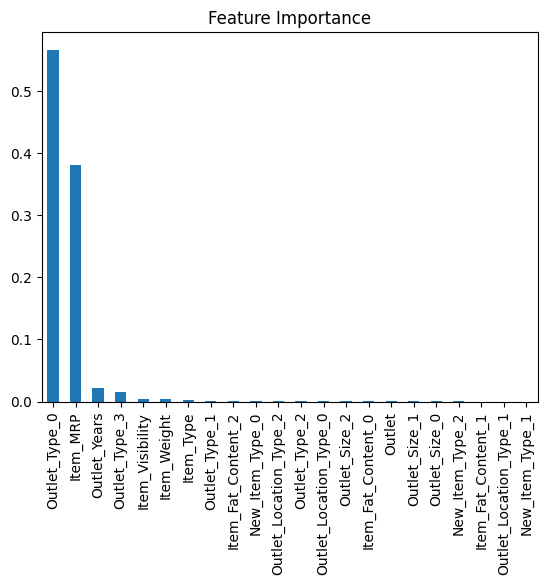

In [238]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=8, max_depth=6, random_state=42)
train(model, X, y)

coef = pd.Series(model.feature_importances_, X.columns).sort_values(ascending=False)
coef.plot(kind='bar', title="Feature Importance")
plt.show()

In [ ]:
def grid_search(X, y, n_list, depth_list):
    best_params = None
    best_mse = float("inf")

    for n in n_list:
        for d in depth_list:
            model = OurRandomForestRegressor(n_estimators=n, max_depth=d)
            model.fit(X, y)
            y_pred = model.predict(X)
            mse_val = np.mean((y - y_pred) ** 2)

            if mse_val < best_mse:
                best_mse = mse_val
                best_params = {"n_estimators": n, "max_depth": d}

    return best_params, best_mse

n_values = [3, 5, 8, 10, 15, 20]
depth_values = [3, 4, 5, 6, 8]

best_params, best_mse = grid_search(X, y, n_values, depth_values)
print("Kết quả Grid Search:")
print(f"   - n_estimators = {best_params['n_estimators']}")
print(f"   - max_depth    = {best_params['max_depth']}")
print(f"   - MSE nhỏ nhất = {best_mse:.4f}")

Variable | Description
----------|--------------
Item_Identifier | Mã sản phẩm
Item_Weight | Trọng lượng của sản phẩm
Item_Fat_Content | Cho biết sản phẩm có hàm lượng chất béo thấp hay không
Item_Visibility | % diện tích trưng bày của sản phẩm
Item_Type | Loại sản phẩm
Item_MRP | Giá bán lẻ tối đa (giá niêm yết) của sản phẩm
Outlet_Identifier | Mã cửa hàng
Outlet_Establishment_Year | Năm thành lập cửa hàng
Outlet_Size | Kích thước cửa hàng dựa trên diện tích mặt bằng
Outlet_Location_Type | Loại thành phố nơi cửa hàng tọa lạc
Outlet_Type | Loại cửa hàng (cửa hàng tạp hóa, siêu thị,...)
Item_Outlet_Sales | Doanh số sản phẩm tại cửa hàng đó (đây là biến kết quả cần dự đoán)